 Required libraries and dependencies





In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor, XGBClassifier


Loading dataset

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/amazon_delivery.csv")
df.head()


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


Creating datetime from date + time and remove invalid rows


In [ ]:
df["Order_Date"] = df["Order_Date"].astype(str).str.strip()
df["Order_Time"] = df["Order_Time"].astype(str).str.strip()

df["datetime"] = pd.to_datetime(
    df["Order_Date"] + " " + df["Order_Time"],
    errors="coerce"
)

df = df.dropna(subset=["datetime"])

print("Remaining rows:", len(df))


Remaining rows: 43648


In [ ]:
df = df.sort_values("datetime").reset_index(drop=True)


Feature engineering

In [ ]:
df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)


In [ ]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2-lat1)
    dlon = np.radians(lon2-lon1)

    a = (np.sin(dlat/2)**2 +
         np.cos(np.radians(lat1)) *
         np.cos(np.radians(lat2)) *
         np.sin(dlon/2)**2)

    return 2 * R * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine(
    df["Store_Latitude"], df["Store_Longitude"],
    df["Drop_Latitude"], df["Drop_Longitude"]
)


Remove Leakage Columns

In [ ]:
df.drop([
    "Order_Date",
    "Order_Time",
    "datetime",
    "Pickup_Time",
    "Order_ID"
], axis=1, inplace=True)


Time-Based Train-Test Split

In [ ]:
split_idx = int(len(df)*0.8)

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

print(len(train_df), len(test_df))


34918 8730


TASK A — ETA PREDICTION (Regression)


In [ ]:
y_train = train_df["Delivery_Time"]
y_test  = test_df["Delivery_Time"]


X_train = train_df.drop("Delivery_Time", axis=1)
X_test  = test_df.drop("Delivery_Time", axis=1)


X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(X_train.shape, X_test.shape)


(34918, 44) (8730, 44)


Baseline: mean predictor


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_pred = np.full(len(y_test), y_train.mean())

print("Baseline MAE:",
      mean_absolute_error(y_test, baseline_pred))


Baseline MAE: 41.67096573894249


Training model(XGBoost Regressor)

In [ ]:
from xgboost import XGBRegressor

reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="rmse"
)

reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

pred = reg.predict(X_test)


Metrics Evaluation

In [ ]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE :", mae)
print("RMSE:", rmse)


MAE : 17.39493751525879
RMSE: 22.30058111280399


Learning curve(Training vs validation RMSE)

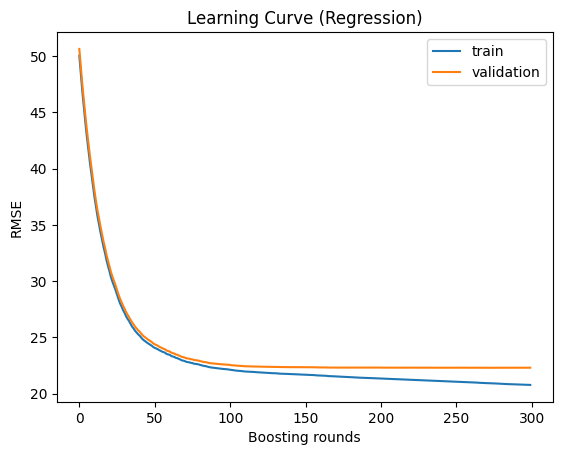

In [ ]:
import matplotlib.pyplot as plt

results = reg.evals_result()

plt.plot(results["validation_0"]["rmse"], label="train")
plt.plot(results["validation_1"]["rmse"], label="validation")
plt.legend()
plt.title("Learning Curve (Regression)")
plt.xlabel("Boosting rounds")
plt.ylabel("RMSE")
plt.show()


Error analysis

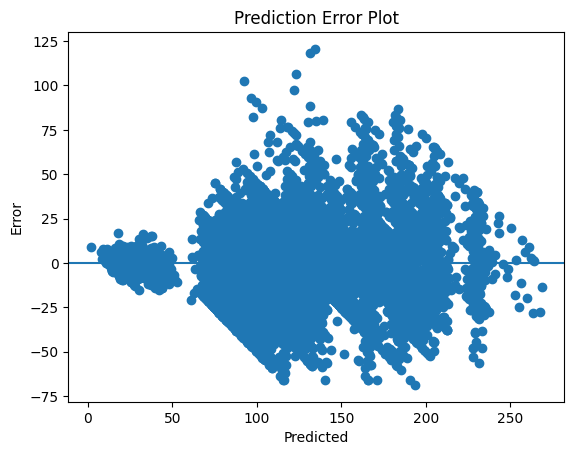

In [ ]:
errors = y_test - pred

plt.scatter(pred, errors)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.title("Prediction Error Plot")
plt.show()


TASK B — DELAY RISK (Classification)

In [ ]:
threshold = train_df["Delivery_Time"].quantile(0.75)

y_train_class = (train_df["Delivery_Time"] > threshold).astype(int)
y_test_class  = (test_df["Delivery_Time"] > threshold).astype(int)

print("Late threshold:", threshold)
print("Late %:", y_train_class.mean())


Late threshold: 160.0
Late %: 0.2302823758519961


In [ ]:
X_train_cls = X_train.copy()
X_test_cls  = X_test.copy()


All-zero baseline

In [ ]:
baseline_pred = np.zeros(len(y_test_class))

from sklearn.metrics import f1_score
print("Baseline F1:", f1_score(y_test_class, baseline_pred))


Baseline F1: 0.0


Training classifier(XGBoost classifier)

In [ ]:
from xgboost import XGBClassifier

clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

clf.fit(
    X_train_cls, y_train_class,
    eval_set=[(X_train_cls, y_train_class), (X_test_cls, y_test_class)],
    verbose=False
)

probs = clf.predict_proba(X_test_cls)[:, 1]


Evaluation metrics

In [ ]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test_class, probs)
preds = (probs > 0.5).astype(int)
f1 = f1_score(y_test_class, preds)

print("ROC AUC:", roc)
print("F1:", f1)


ROC AUC: 0.9655918152613107
F1: 0.8180924287118977


Learning curve

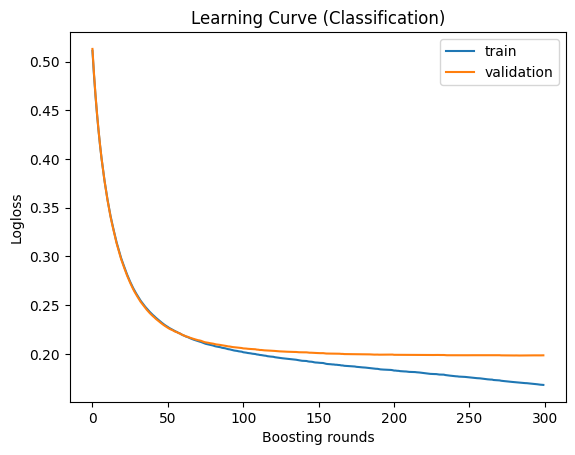

In [ ]:
results = clf.evals_result()

plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="validation")
plt.legend()
plt.title("Learning Curve (Classification)")
plt.xlabel("Boosting rounds")
plt.ylabel("Logloss")
plt.show()
